Libraries loaded successfully.
All helper definitions ready.
Simulation results loaded.
Loading IBM real-device data...
IBM data: 1000 shots
Using device: cpu
Evaluating MWPM on IBM...
Evaluating CNN on IBM...
Evaluating Transformer (Hybrid) on IBM...
IBM evaluation complete.

FINAL DECODER EVALUATION: SIMULATION VS. REAL HARDWARE (Distance-3)
Decoder                      | Symmetric   | Asymmetric  | IBM Real   
----------------------------------------------------------------------
MWPM (Baseline)              | 0.1500      | 0.1990      | 0.5050     
CNN                          | 0.1115      | 0.1515      | 0.5140     
Transformer (Scratch)        | 0.0725      | 0.1305      | —          
Transformer (Hybrid 2-Stage) | —           | 0.1265      | 0.4970     


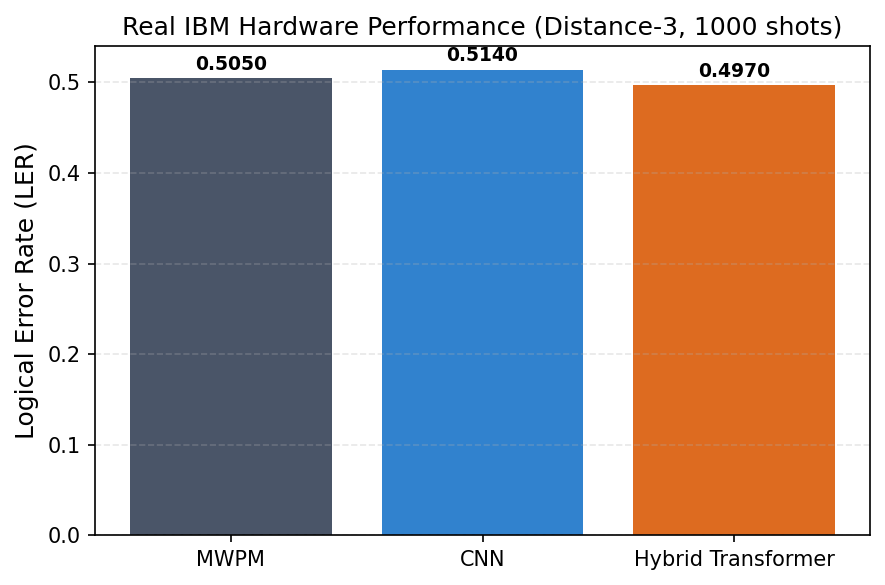


Plot saved as 'final_master_evaluation.png'
All done.


In [ ]:
!pip install pymatching --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pymatching
import os

print("Libraries loaded successfully.")

# ---- MWPM helpers ----
def extract_detection_events(syndrome_matrix, num_rounds=5, num_ancillas=8):
    if hasattr(syndrome_matrix, 'values'):
        syndrome_matrix = syndrome_matrix.values
    reshaped = syndrome_matrix.reshape(-1, num_rounds, num_ancillas)
    detection_events = np.zeros_like(reshaped)
    detection_events[:, 0, :] = reshaped[:, 0, :]
    for r in range(1, num_rounds):
        detection_events[:, r, :] = reshaped[:, r, :] ^ reshaped[:, r-1, :]
    return detection_events.reshape(-1, num_rounds * num_ancillas)

def build_optimized_mwpm_graph(stabilizer_map, top_qubits, num_rounds=5):
    num_ancillas = len(stabilizer_map)
    mwpm = pymatching.Matching()
    boundary_node = num_rounds * num_ancillas
    spatial_edges = []
    for i in range(num_ancillas):
        for j in range(i+1, num_ancillas):
            if i%2 == j%2 and len(set(stabilizer_map[i][1]).intersection(stabilizer_map[j][1])) > 0:
                spatial_edges.append((i,j))
    boundary_ancillas = []
    for i, (_, data_qs) in enumerate(stabilizer_map):
        if i%2 != 0 and len(set(data_qs).intersection(top_qubits)) > 0:
            boundary_ancillas.append(i)
    for r in range(num_rounds):
        for i in range(num_ancillas):
            node_idx = r*num_ancillas + i
            if i in boundary_ancillas:
                mwpm.add_edge(node_idx, boundary_node, weight=2.0, fault_ids=0)
            else:
                mwpm.add_edge(node_idx, boundary_node, weight=2.0)
            if r < num_rounds - 1:
                mwpm.add_edge(node_idx, (r+1)*num_ancillas + i, weight=1.0)
        for (a,b) in spatial_edges:
            mwpm.add_edge(r*num_ancillas + a, r*num_ancillas + b, weight=1.5)
    mwpm.set_boundary_nodes({boundary_node})
    return mwpm

stabilizer_map_d3 = [
    (0, [0,1,3,4]), (2, [1,2,4,5]), (4, [3,4,6,7]), (6, [4,5,7,8]),
    (1, [0,3]), (3, [1,2,4,5]), (5, [3,4,6,7]), (7, [5,8])
]
top_boundary_qubits_d3 = [0,1,2]

# ---- CNN model ----
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32*1*2, 64)
        self.fc2 = nn.Linear(64, 1)
    def forward(self, x):
        x = x.view(-1, 1, 5, 8)
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

# ---- Transformer model ----
class RecurrentTransformerBaseline(nn.Module):
    def __init__(self, num_rounds=5, ancillas_per_round=8, d_model=32, nhead=4, dropout_rate=0.2):
        super().__init__()
        self.num_rounds = num_rounds
        self.ancillas_per_round = ancillas_per_round
        self.embedding = nn.Linear(ancillas_per_round, d_model)
        self.gru = nn.GRU(d_model, d_model, batch_first=True)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=64,
                                                   dropout=dropout_rate, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(d_model, 1)
    def forward(self, x):
        x = x.view(-1, self.num_rounds, self.ancillas_per_round)
        x = torch.relu(self.embedding(x))
        x, _ = self.gru(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        return torch.sigmoid(self.classifier(x))

print("All helper definitions ready.")


def ler(df, pred_col):
    return np.mean(df['GroundTruth'] != df[pred_col])

results = {}

sim_files = {
    'mwpm_sym': 'mwpm_results_pretrain.csv',
    'mwpm_asym': 'mwpm_results_finetune.csv',
    'cnn_sym': 'cnn_results_path_b.csv',
    'cnn_asym': 'cnn_results_path_c.csv',
    'trans_sym': 'transformer_results_path_b.csv',
    'trans_asym_scratch': 'transformer_results_path_b_asym.csv',
    'trans_hybrid_asym': 'transformer_results_path_c.csv',
}

for key, fname in sim_files.items():
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        # Determine the prediction column name
        if 'MWPM_Prediction' in df.columns:
            pred_col = 'MWPM_Prediction'
        elif 'CNN_B_Prediction' in df.columns:
            pred_col = 'CNN_B_Prediction'
        elif 'CNN_C_Prediction' in df.columns:
            pred_col = 'CNN_C_Prediction'
        elif 'Path_B_Prediction' in df.columns:
            pred_col = 'Path_B_Prediction'
        elif 'Path_B_Asym_Prediction' in df.columns:
            pred_col = 'Path_B_Asym_Prediction'
        elif 'Path_C_Prediction' in df.columns:
            pred_col = 'Path_C_Prediction'
        else:
            raise ValueError(f"No known prediction column in {fname}")
        results[key] = ler(df, pred_col)
    else:
        results[key] = None
        print(f"Warning: {fname} not found. Skipping.")

# If any file missing, raise error
missing = [k for k,v in results.items() if v is None]
if missing:
    raise FileNotFoundError(f"Missing files: {missing}")

print("Simulation results loaded.")

#LOAD & EVALUATE REAL IBM HARDWARE DATA
print("Loading IBM real-device data...")
ibm_features = pd.read_csv('features_realdevice.csv').values
ibm_labels   = pd.read_csv('labels_realdevice.csv').values.ravel()
print(f"IBM data: {len(ibm_features)} shots")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
BATCH_SIZE = 128

# ---- MWPM ----
print("Evaluating MWPM on IBM...")
mwpm_graph = build_optimized_mwpm_graph(stabilizer_map_d3, top_boundary_qubits_d3, num_rounds=5)
detect_ibm = extract_detection_events(ibm_features, num_rounds=5, num_ancillas=8)
preds_mwpm_ibm = mwpm_graph.decode_batch(detect_ibm).flatten()
results['MWPM_ibm'] = np.mean(preds_mwpm_ibm != ibm_labels)

# ---- CNN ----
print("Evaluating CNN on IBM...")
cnn_model = SimpleCNN().to(device)
cnn_model.load_state_dict(torch.load('best_cnn.pth', map_location=device))
cnn_model.eval()
preds_cnn = []
with torch.no_grad():
    for i in range(0, len(ibm_features), BATCH_SIZE):
        batch = torch.tensor(ibm_features[i:i+BATCH_SIZE], dtype=torch.float32).to(device)
        preds_cnn.extend((cnn_model(batch) >= 0.5).int().cpu().numpy().flatten())
results['CNN_ibm'] = np.mean(np.array(preds_cnn) != ibm_labels)

# ---- Transformer (Hybrid 2-Stage) ----
print("Evaluating Transformer (Hybrid) on IBM...")
trans_model = RecurrentTransformerBaseline().to(device)
trans_model.load_state_dict(torch.load('path_c_asymmetric_best.pth', map_location=device))
trans_model.eval()
preds_trans = []
with torch.no_grad():
    for i in range(0, len(ibm_features), BATCH_SIZE):
        batch = torch.tensor(ibm_features[i:i+BATCH_SIZE], dtype=torch.float32).to(device)
        preds_trans.extend((trans_model(batch) >= 0.5).int().cpu().numpy().flatten())
results['Transformer_hybrid_ibm'] = np.mean(np.array(preds_trans) != ibm_labels)

print("IBM evaluation complete.")


print("\n" + "="*70)
print("FINAL DECODER EVALUATION: SIMULATION VS. REAL HARDWARE (Distance-3)")
print("="*70)
print(f"{'Decoder':<28} | {'Symmetric':<11} | {'Asymmetric':<11} | {'IBM Real':<11}")
print("-" * 70)
print(f"{'MWPM (Baseline)':<28} | {results['mwpm_sym']:<11.4f} | {results['mwpm_asym']:<11.4f} | {results['MWPM_ibm']:<11.4f}")
print(f"{'CNN':<28} | {results['cnn_sym']:<11.4f} | {results['cnn_asym']:<11.4f} | {results['CNN_ibm']:<11.4f}")
print(f"{'Transformer (Scratch)':<28} | {results['trans_sym']:<11.4f} | {results['trans_asym_scratch']:<11.4f} | {'—':<11}")
print(f"{'Transformer (Hybrid 2-Stage)':<28} | {'—':<11} | {results['trans_hybrid_asym']:<11.4f} | {results['Transformer_hybrid_ibm']:<11.4f}")
print("="*70)


fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
decoders = ['MWPM', 'CNN', 'Hybrid Transformer']
ibm_ler = [results['MWPM_ibm'], results['CNN_ibm'], results['Transformer_hybrid_ibm']]
bars = ax.bar(decoders, ibm_ler, color=['#4A5568', '#3182CE', '#DD6B20'])
ax.set_ylabel('Logical Error Rate (LER)', fontsize=12)
ax.set_title('Real IBM Hardware Performance (Distance‑3, 1000 shots)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for bar, val in zip(bars, ibm_ler):
    ax.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ibm_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'final_master_evaluation.png'")
print("All done.")